In [1]:
import os
import ast
import math
import pickle
import re
import sys

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = False
import numpy as np
import pandas as pd
from sklearn.metrics import matthews_corrcoef
from tqdm import tqdm

sys.path.insert(0, '..')
from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, FONT_SIZES

plt.rcParams['figure.dpi'] = 300
plt.rcParams.update(FONT_SIZES)

In [4]:
# Map each read length to its data_type string
#DATA_TYPE_TEMPLATE = "with_errors_3.75e-05i_0.03s_{bp}bp" #stress-error
DATA_TYPE_TEMPLATE = "with_errors_5e-06i_0.004s_{bp}bp"    #typical-error
#DATA_TYPE_TEMPLATE = "with_errors_1.25e-05i_0.01s_{bp}bp" #high-error

# Toggle: set True to load pre-computed results from disk (fast), False to run full data processing
LOAD_PROCESSED_DATA = True

In [5]:
project_root = "../../../.."

all_test_accessions = open(f"{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt").read().splitlines()

# Load genome info from CSV and create dict for all test accessions
genome_info_df = pd.read_csv(f"{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv")
genome_info_df = genome_info_df.set_index('accession')

# Families that use translation table 4 (Mycoplasmataceae and related)
TT4_FAMILIES = ['Mycoplasmataceae']

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        # Assign translation table based on family
        translation_table = 4 if row['family'] in TT4_FAMILIES else 11
        all_genomes[acc] = {
            'family': row['family'],
            'domain': row['domain'],
            'gc_content': row['gc_content'],
            'translation_table': translation_table
        }

# Create filtered accession lists by translation table
tt4_accessions = [acc for acc in all_test_accessions if acc in all_genomes and all_genomes[acc]['translation_table'] == 4]
tt11_accessions = [acc for acc in all_test_accessions if acc in all_genomes and all_genomes[acc]['translation_table'] == 11]

print(f"Translation Table 4 genomes: {len(tt4_accessions)}")
print(f"Translation Table 11 genomes: {len(tt11_accessions)}")

#"Reference" test accessions (1 per family); often used in prokaryotic gene finding benchmarks
genomes = {
    'GCF_000011125.1': {'translation_table': 11, 'gc_content': 56.3, 'domain': 'Archaea'},
    'GCF_000008665.1': {'translation_table': 11, 'gc_content': 48.6, 'domain': 'Archaea'},
    'GCF_004799605.1': {'translation_table': 11, 'gc_content': 66.3, 'domain': 'Archaea'},
    'GCF_000017165.1': {'translation_table': 11, 'gc_content': 31.3, 'domain': 'Archaea'},
    'GCF_000007345.1': {'translation_table': 11, 'gc_content': 42.7, 'domain': 'Archaea'},
    'GCF_000012545.1': {'translation_table': 11, 'gc_content': 27.6, 'domain': 'Archaea'},
    'GCF_000007365.1': {'translation_table': 11, 'gc_content': 25.3, 'domain': 'Bacteria'},
    'GCF_000009045.1': {'translation_table': 11, 'gc_content': 43.5, 'domain': 'Bacteria'},
    'GCF_025998455.1': {'translation_table': 11, 'gc_content': 38.5, 'domain': 'Bacteria'},
    'GCF_000195955.2': {'translation_table': 11, 'gc_content': 65.6, 'domain': 'Bacteria'},
    'GCF_020736045.1': {'translation_table': 11, 'gc_content': 38.2, 'domain': 'Bacteria'},
    'GCF_000012765.1': {'translation_table': 4, 'gc_content': 23.8, 'domain': 'Bacteria'},
    'GCF_028609885.1': {'translation_table': 11, 'gc_content': 61.4, 'domain': 'Bacteria'},
    'GCF_000005845.2': {'translation_table': 11, 'gc_content': 50.8, 'domain': 'Bacteria'},
    'GCF_000006765.1': {'translation_table': 11, 'gc_content': 66.6, 'domain': 'Bacteria'},
    'GCF_000013425.1': {'translation_table': 11, 'gc_content': 32.9, 'domain': 'Bacteria'}}

test_accessions = list(genomes.keys()) #List of the "reference" test accessions 

_script_name = "indel_reads_mae"
_error_rate_key = DATA_TYPE_TEMPLATE.replace("_{bp}bp", "")
_cache_dir = (f"{project_root}/data/processed_data/report_results/"
             f"with_errors/{_script_name}/{_error_rate_key}")

Translation Table 4 genomes: 3
Translation Table 11 genomes: 212


In [6]:
def get_indel_positions(reads_dict):

    seq_errors_read_dict = {}

    for read in reads_dict.keys():
        cds_fragments_connections = reads_dict[read]['cds_fragments_connection']
        cds_coords = reads_dict[read]['cds_coords']
        seq_error_info = reads_dict[read]['seq_error_positions']

        if len(seq_error_info) == 0:
            continue

        seq_errors_read_dict[read] = seq_error_info


    return seq_errors_read_dict

In [7]:
def load_in_processed_datasets(test_accession, data_type, project_root=project_root):
    #Load in testset data
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/testset_dict.pkl", "rb") as testset_dict_file:
        testset_dict = pickle.load(testset_dict_file)

    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/read_names_list.pkl", "rb") as read_names_list_file:
        read_names_list = pickle.load(read_names_list_file)

    with open(f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_illumina_5/{test_accession}.pkl", "rb") as preds_fgs_dict_file:
        preds_fgs_illumina_5 = pickle.load(preds_fgs_dict_file)

    with open(f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_illumina_10/{test_accession}.pkl", "rb") as preds_fgs_dict_file:
        preds_fgs_illumina_10 = pickle.load(preds_fgs_dict_file)


    with open(f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_with_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl", "rb") as model_preds_dict_file:
        preds_deep_cds_errors = pickle.load(model_preds_dict_file)

    return read_names_list, get_indel_positions(testset_dict), \
        get_indel_positions(preds_fgs_illumina_5), get_indel_positions(preds_fgs_illumina_10), get_indel_positions(preds_deep_cds_errors)

In [8]:
def calculate_mae(testset_dict, preds_dict):
    err_positions = []
    indel_TP = 0
    indel_FP = 0
    indel_FN = 0

    in_testset = testset_dict.keys()
    in_preds   = preds_dict.keys()

    intersections   = list(set(in_testset).intersection(set(in_preds)))
    only_in_testset = list(set(in_testset).difference(set(in_preds)))
    only_in_preds   = list(set(in_preds).difference(set(in_testset)))

    # Reads with indels in testset but no predicted indel: all testset indels are FN
    for read in only_in_testset:
        indel_FN += len(testset_dict[read])

    # Reads with predicted indels but no testset indel: all predicted indels are FP
    for read in only_in_preds:
        indel_FP += len(preds_dict[read])

    # Reads with indels in both: greedy one-to-one matching by minimum distance
    for read in intersections:
        testset_err = [int(re.match(r"\d+", v).group()) for v in testset_dict[read]]
        preds_err   = [int(re.match(r"\d+", v).group()) for v in preds_dict[read]]

        pairs = sorted(
            (abs(t - p), ti, pi)
            for ti, t in enumerate(testset_err)
            for pi, p in enumerate(preds_err)
        )
        matched_t = set()
        matched_p = set()
        for dist, ti, pi in pairs:
            if ti not in matched_t and pi not in matched_p:
                err_positions.append(dist)
                matched_t.add(ti)
                matched_p.add(pi)

        indel_TP += len(matched_t)
        indel_FN += len(testset_err) - len(matched_t)
        indel_FP += len(preds_err)   - len(matched_p)

    precision   = indel_TP / (indel_TP + indel_FP) if (indel_TP + indel_FP) > 0 else 0
    sensitivity = indel_TP / (indel_TP + indel_FN) if (indel_TP + indel_FN) > 0 else 0

    return indel_TP, indel_FN, indel_FP, np.mean(err_positions) if err_positions else np.nan, precision, sensitivity

In [10]:
import sys
sys.path.insert(0, '..')
from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, FONT_SIZES
 
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update(FONT_SIZES)
 
# ── Configuration ──────────────────────────────────────────────────────────────
 
READ_LENGTHS = [75, 100, 150, 300]          # bp — adjust order if desired
DATA_TYPES = {bp: DATA_TYPE_TEMPLATE.format(bp=bp) for bp in READ_LENGTHS}
 

if "5e-06i_0.004s" in DATA_TYPES[75]:
    error_rate_title = r"0.001\% indel error rate, 0.4\% substitution error rate per base"
elif "1.25e-05i_0.01s" in DATA_TYPES[75]:
    error_rate_title = r"0.0025\% indel error rate, 1\% substitution error rate per base"
elif "3.75e-05i_0.03s" in DATA_TYPES[75]:
    error_rate_title = r"0.0075\% indel error rate, 3\% substitution error rate per base"

MODEL_KEYS = [
    "fgs_illumina_5",
    "fgs_illumina_10",
    "deep_cds_errors"]

In [12]:
if not LOAD_PROCESSED_DATA:
    # ── Cell 1: Collect metrics — all models × all read lengths × all accessions ──
 
    # results[bp][model_key] = {"precisions": [...], "sensitivities": [...],
    #                            "MAEs": [...], "f1s": [...]}
    results = {
        bp: {key: {"precisions": [], "sensitivities": [], "MAEs": [], "f1s": []}
             for key in MODEL_KEYS}
        for bp in READ_LENGTHS
    }

    # indel_density_results[bp] = list of (total_indels / (n_reads * bp)) per genome
    indel_density_results = {bp: [] for bp in READ_LENGTHS}
 
    for bp in READ_LENGTHS:
        data_type = DATA_TYPES[bp]
        print(f"\nCollecting metrics for {bp} bp reads …")
    
        #Exclude the three test genomes with alternative translation table 
        for test_accession in tqdm(tt11_accessions):
            (read_names_list, testset_dict,
            preds_fgs_illumina_5, preds_fgs_illumina_10, preds_deep_cds_errors
            ) = load_in_processed_datasets(test_accession, data_type,
                                        project_root=project_root)
 
            # Indel density: total indel positions across all reads / total base positions
            total_indels = sum(len(v) for v in testset_dict.values())
            total_positions = len(read_names_list) * bp
            indel_density_results[bp].append(
                total_indels / total_positions if total_positions > 0 else 0.0
            )

            pred_dicts = {
                "fgs_illumina_5":     preds_fgs_illumina_5,
                "fgs_illumina_10":    preds_fgs_illumina_10,
                "deep_cds_errors":    preds_deep_cds_errors,
            }
 
            for key, pred_dict in pred_dicts.items():
                TP, FN, FP, MAE, precision, sensitivity = calculate_mae(
                    testset_dict, pred_dict
                )
                f1 = (2 * precision * sensitivity / (precision + sensitivity)
                      if (precision + sensitivity) > 0 else 0.0)
 
                r = results[bp][key]
                r["precisions"].append(precision)
                r["sensitivities"].append(sensitivity)
                r["MAEs"].append(MAE)
                r["f1s"].append(f1)
 
else:

    print(f"Loading pre-computed results from:\n  {_cache_dir}")
    with open(os.path.join(_cache_dir, "results.pkl"), "rb") as f:
        results = pickle.load(f)
    with open(os.path.join(_cache_dir, "indel_density_results.pkl"), "rb") as f:
        indel_density_results = pickle.load(f)

Loading pre-computed results from:
  ../../../../data/processed_data/report_results/with_errors/indel_reads_mae/with_errors_5e-06i_0.004s


In [13]:
if not LOAD_PROCESSED_DATA:
    os.makedirs(_cache_dir, exist_ok=True)
    _objects_to_save = {
        "results": results,
        "indel_density_results": indel_density_results,
    }
    for _name, _obj in _objects_to_save.items():
        with open(os.path.join(_cache_dir, f"{_name}.pkl"), "wb") as f:
            pickle.dump(_obj, f)
    print(f"Results saved to {_cache_dir}")

In [16]:
#Plot boxplots
def plot_metric_boxplot(metric_key, ylabel, filename,
                        title=None, ylim=(0, 1.05)):
    """
    One standalone figure per metric.
 
    X-axis: one group per read length (75 / 100 / 150 / 300 bp).
    Within each group: one box per model, coloured by MODEL_COLORS.
    NaN values (e.g. MAE when TP=0) are dropped before plotting; the count
    of dropped genomes is annotated below each box as "*NA=N".
    Legend identifies models.
    """
    n_models      = len(MODEL_KEYS)
    n_lengths     = len(READ_LENGTHS)
    group_width   = 0.8
    box_width     = group_width / n_models
    offsets       = [(i - (n_models - 1) / 2) * box_width
                     for i in range(n_models)]
    group_centres = list(range(n_lengths))
 
    matplotlib.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(figsize=(10, 7))
 
    # Reserve a little space at the bottom of the axes for NA annotations
    ax.set_clip_on(False)
 
    legend_handles = []
 
    for m_idx, key in enumerate(MODEL_KEYS):
        color = MODEL_COLORS[key]
        label = MODEL_DISPLAY_NAMES[key]
 
        for g_idx, bp in enumerate(READ_LENGTHS):
            raw  = results[bp][key][metric_key]
            data = [v for v in raw if not np.isnan(v)]
            n_na = len(raw) - len(data)
            pos  = group_centres[g_idx] + offsets[m_idx]
 
            if len(data) > 0:
                bp_dict = ax.boxplot(
                    [data],
                    positions=[pos],
                    widths=box_width * 0.85,
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color=color, linewidth=1.2),
                    capprops=dict(color=color, linewidth=1.2),
                    flierprops=dict(marker='o', markersize=3,
                                    markerfacecolor=color,
                                    markeredgecolor=color,
                                    linestyle='none', alpha=0.6),
                    showfliers=True,
                )
                bp_dict['boxes'][0].set_facecolor(color)
                bp_dict['boxes'][0].set_alpha(0.80)
 
            # Annotate NA count below the x-axis for this box position
            if n_na > 0:
                ax.annotate(
                    f"*NA={n_na}",
                    xy=(pos, 0), xycoords=('data', 'axes fraction'),
                    xytext=(0, -38), textcoords='offset points',
                    ha='center', va='top',
                    fontsize=7, color=color,
                    annotation_clip=False,
                )
 
        legend_handles.append(
            plt.matplotlib.patches.Patch(facecolor=color, alpha=0.80,
                                         label=label)
        )
 
    ax.set_xticks(group_centres)
    ax.set_xticklabels([f"{bp} bp" for bp in READ_LENGTHS])
    ax.set_xlim(-0.6, n_lengths - 0.4)
 
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Read length")
 
    if ylim is not None:
        ax.set_ylim(*ylim)
 
    if title:
        ax.set_title(title, fontsize=15)
 
    ax.legend(handles=legend_handles,
              bbox_to_anchor=(0.5, -0.2), loc='lower center',
              borderaxespad=0, frameon=False, ncols = 4)
 
    ax.grid(True, axis='y', alpha=0.3, linewidth=0.8)
 
    # Extra bottom margin so NA annotations don't get clipped
    plt.subplots_adjust(bottom=0.2)
    # plt.savefig(filename, bbox_inches='tight', dpi=500)
    plt.show()
 

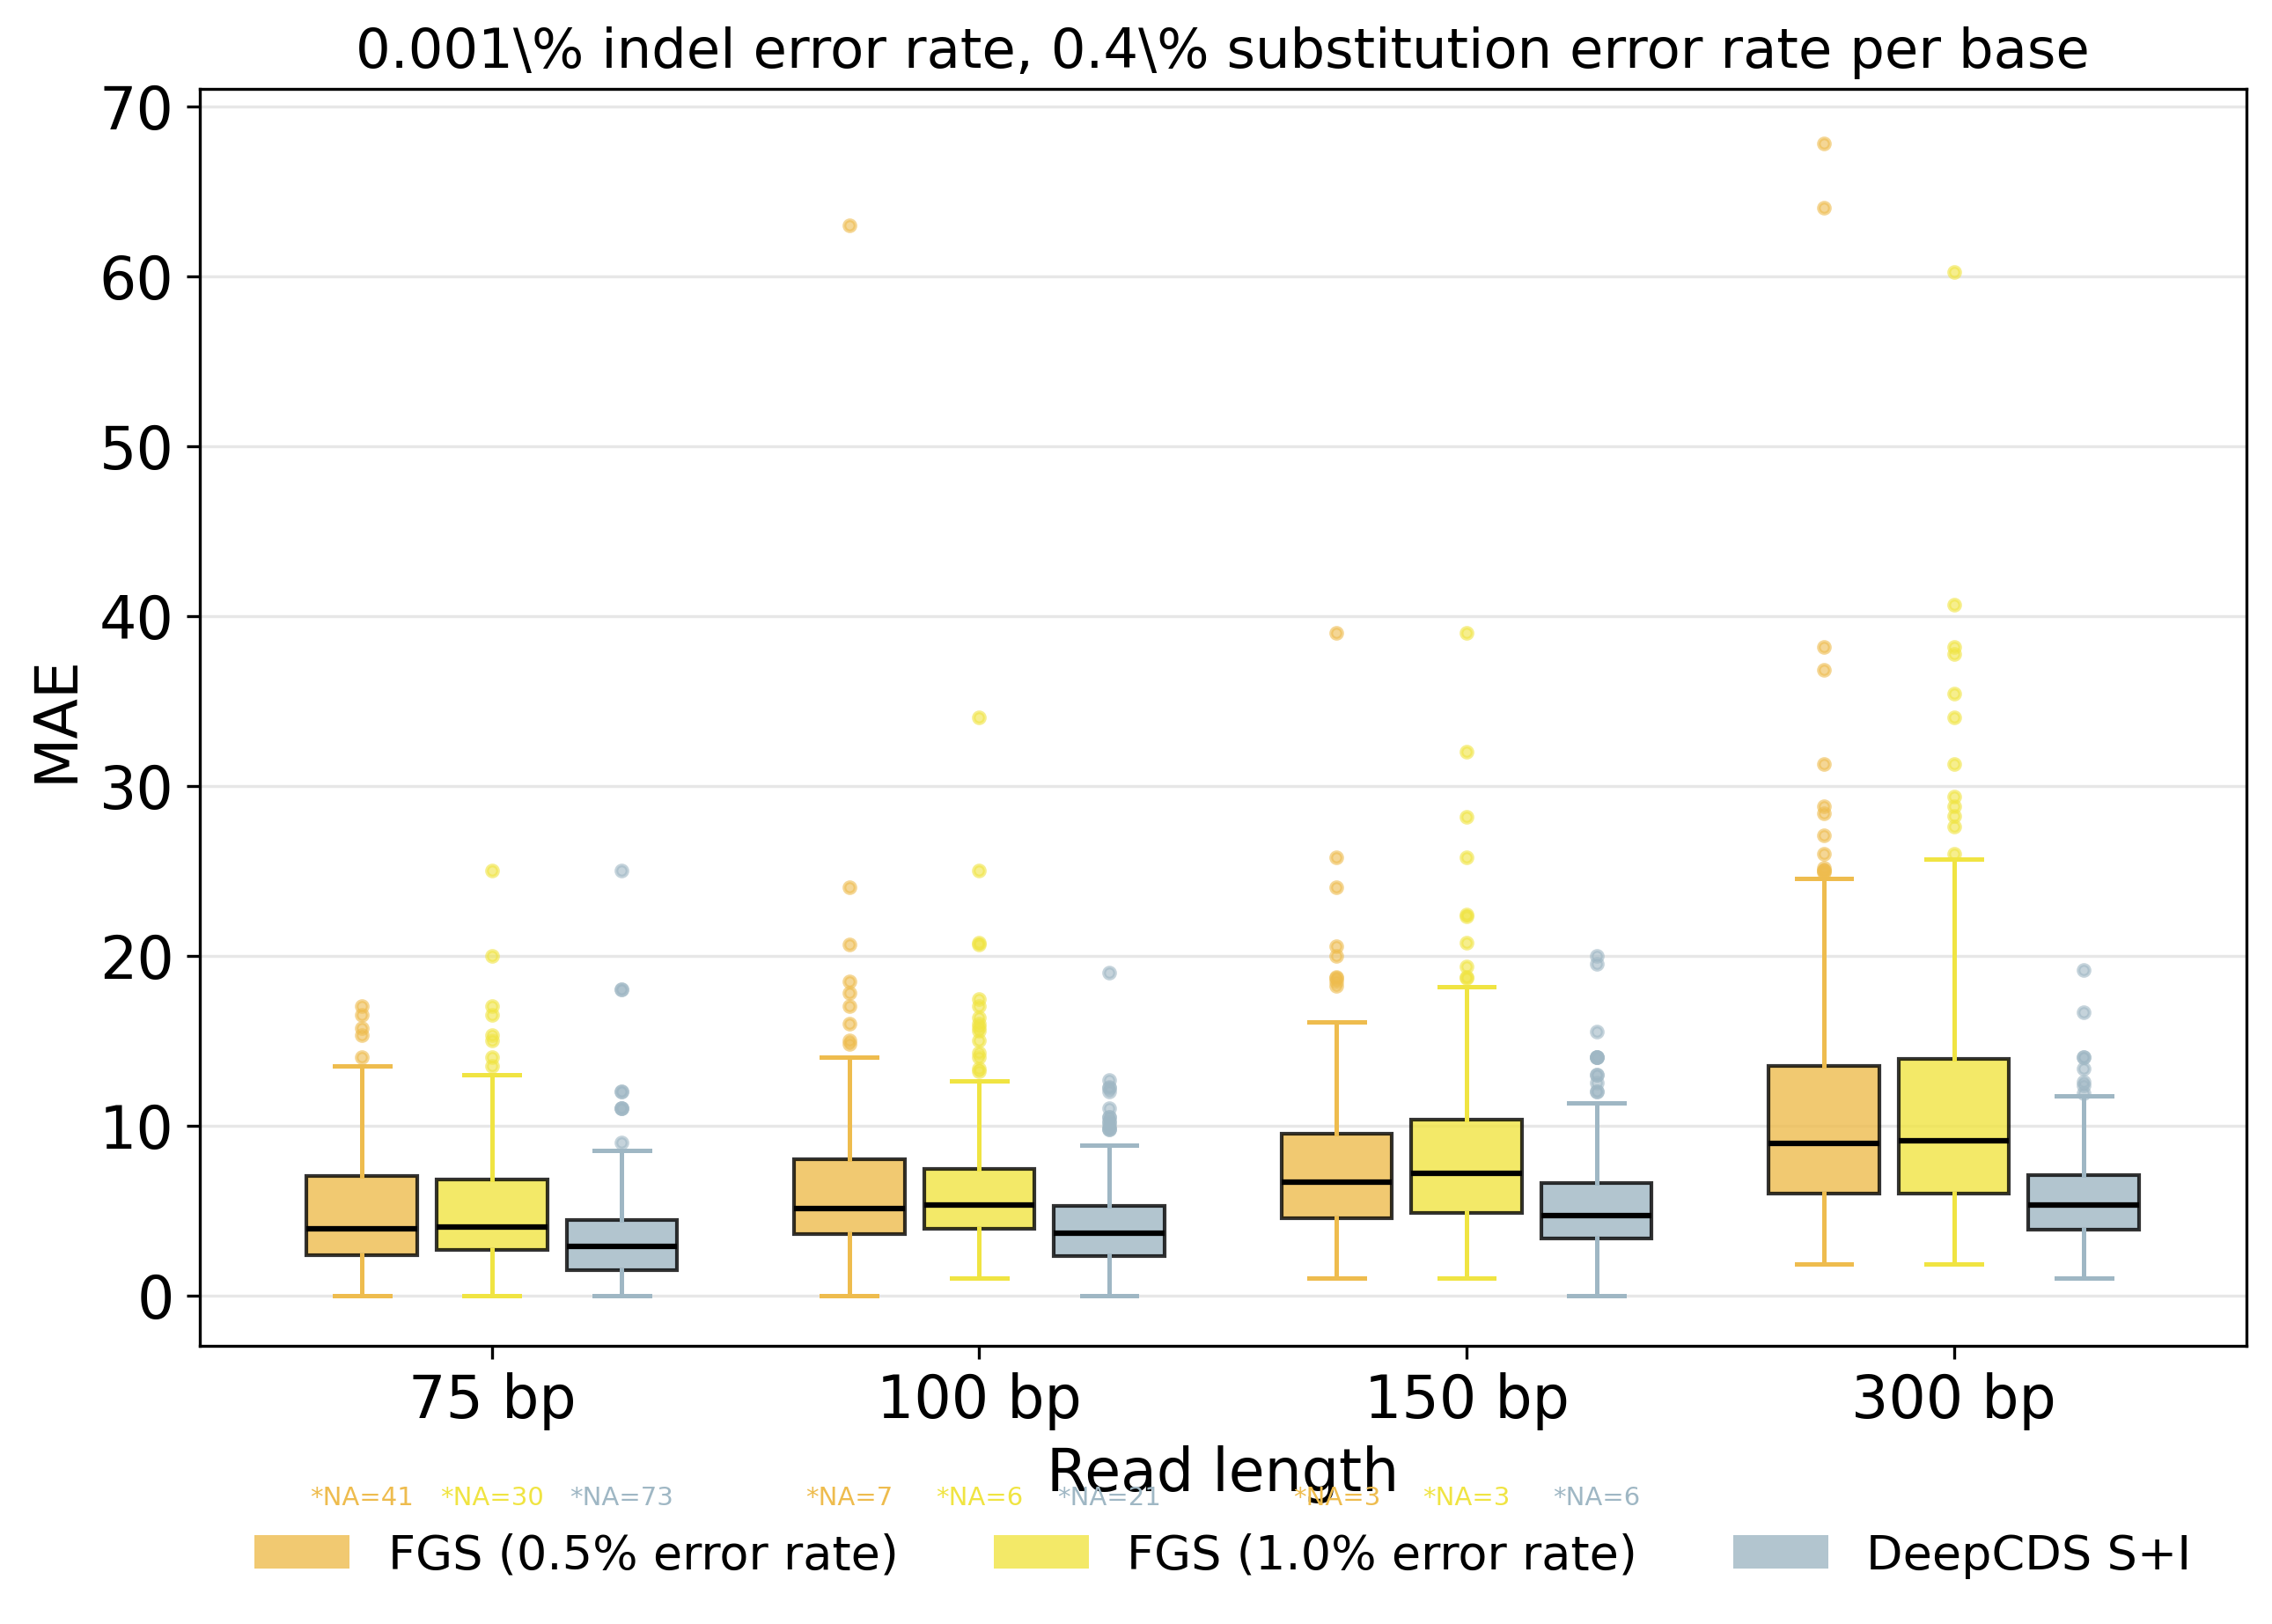

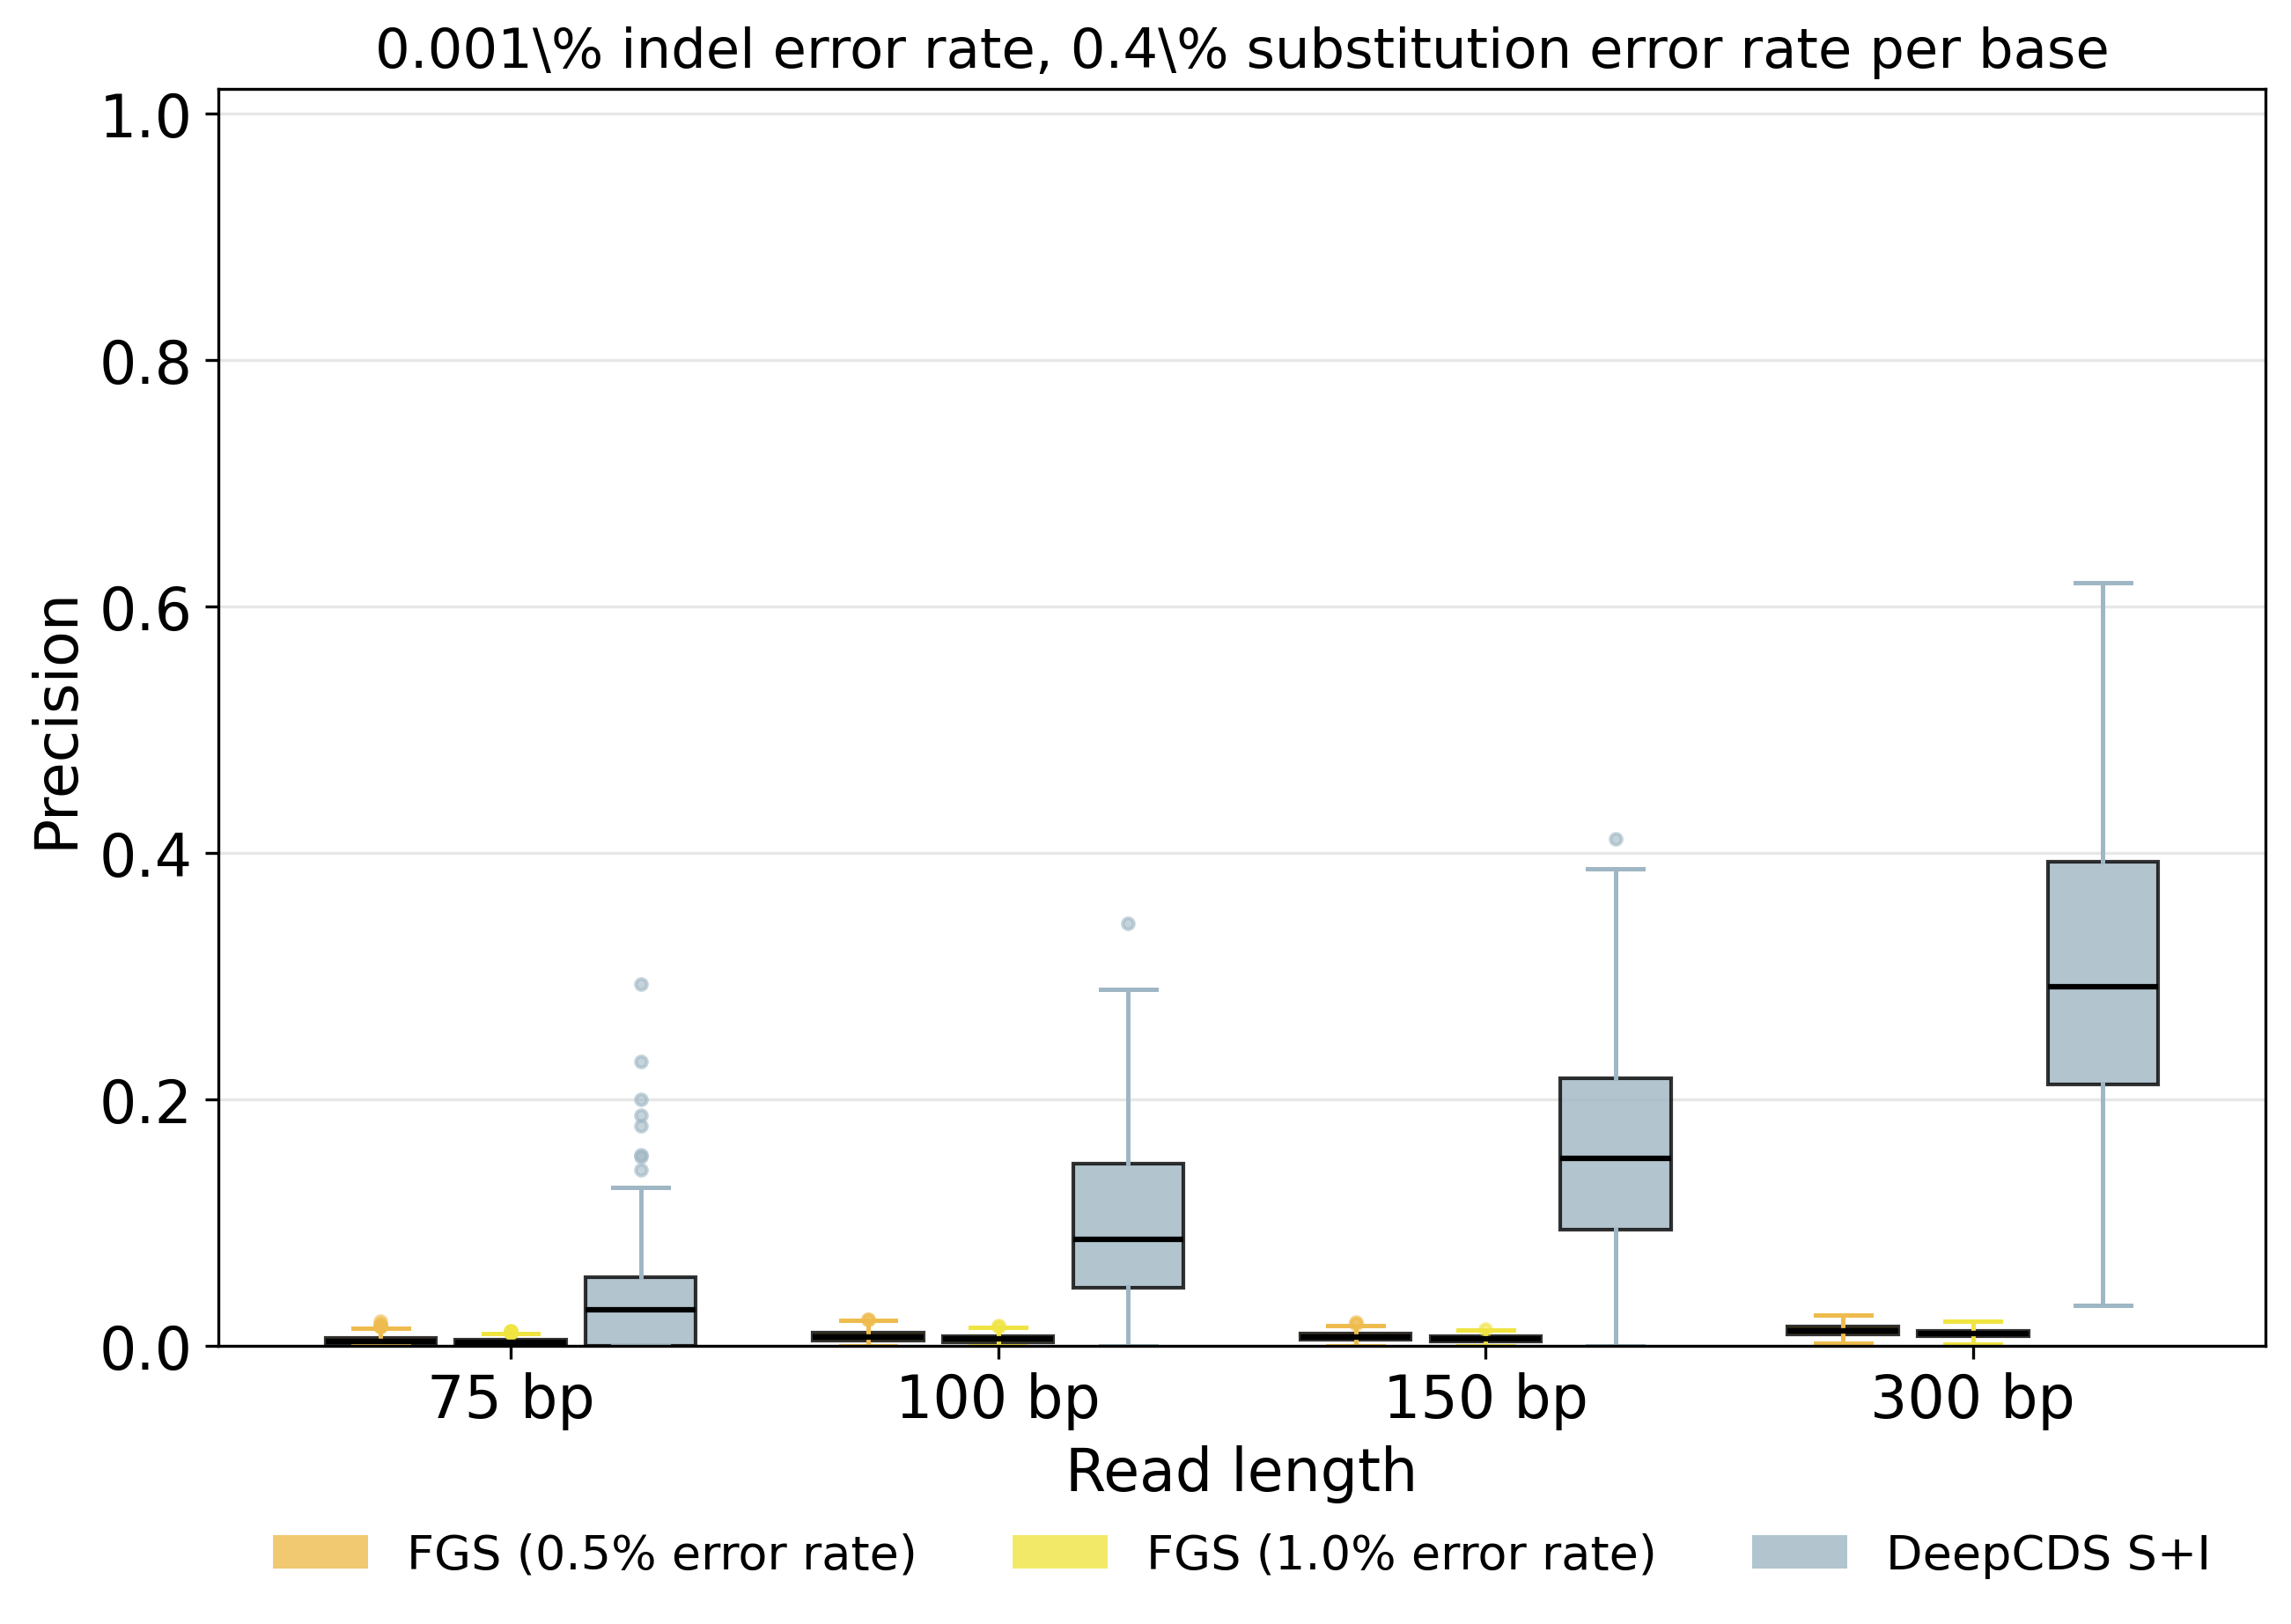

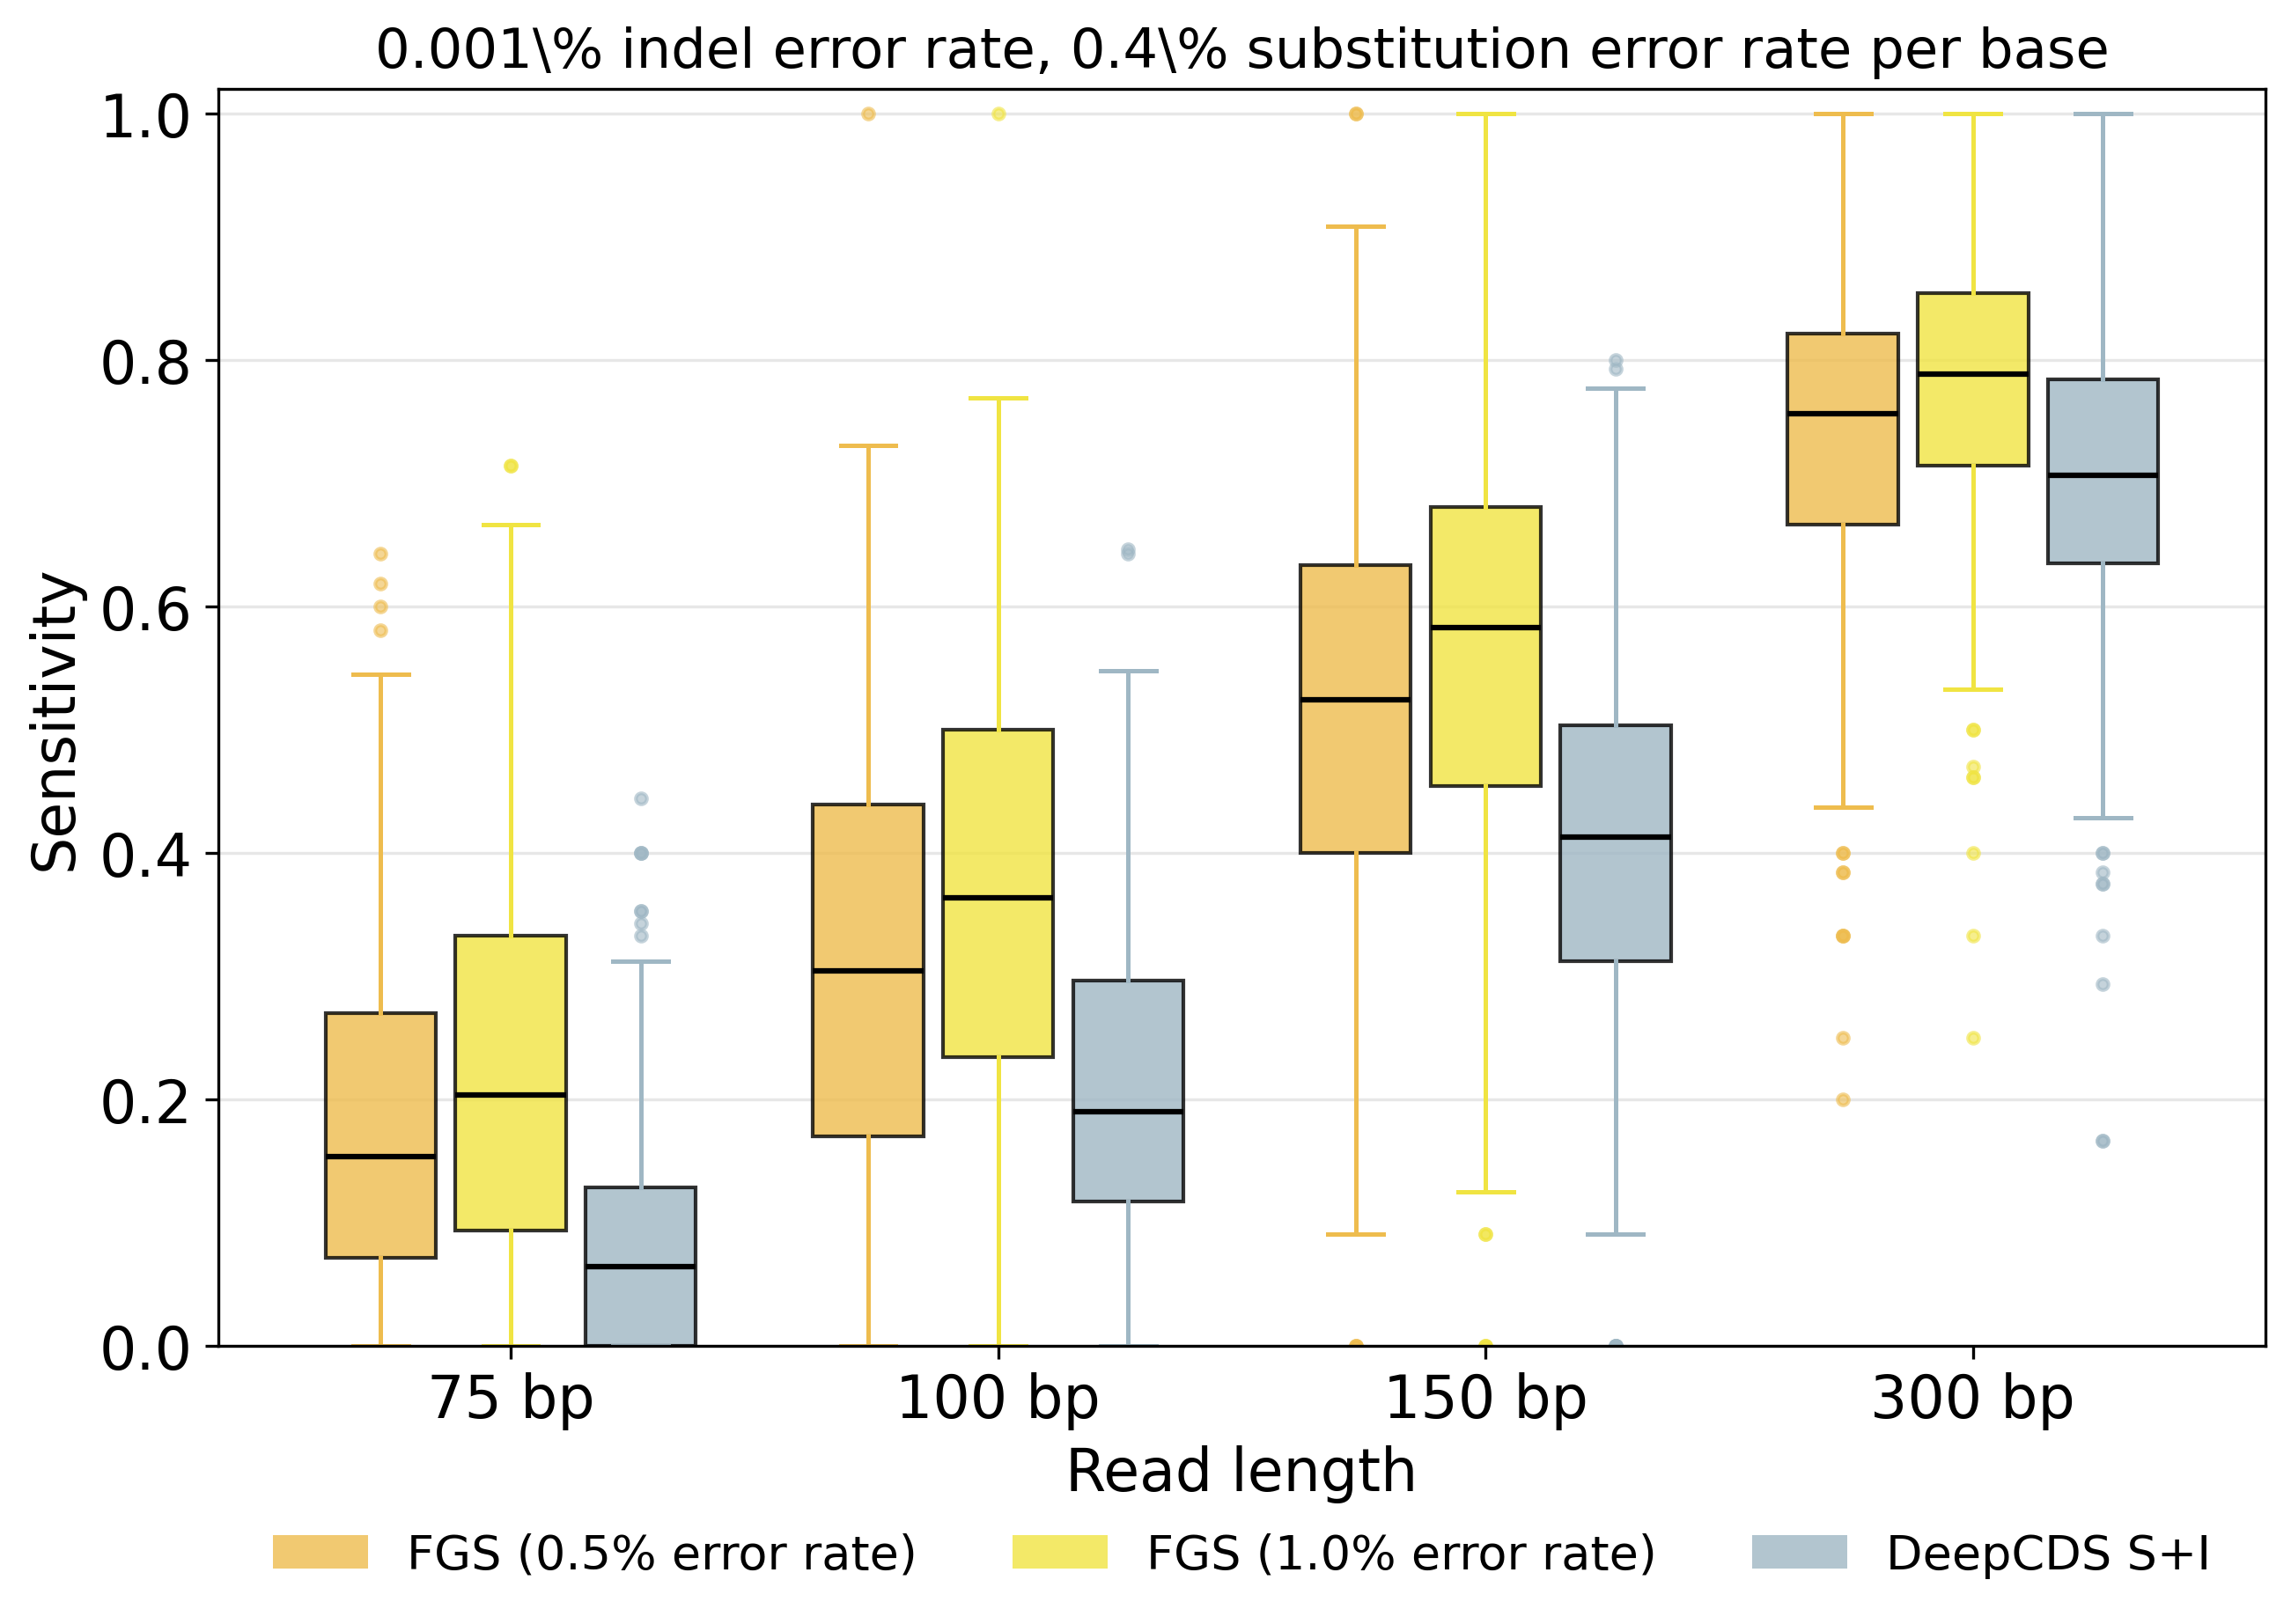

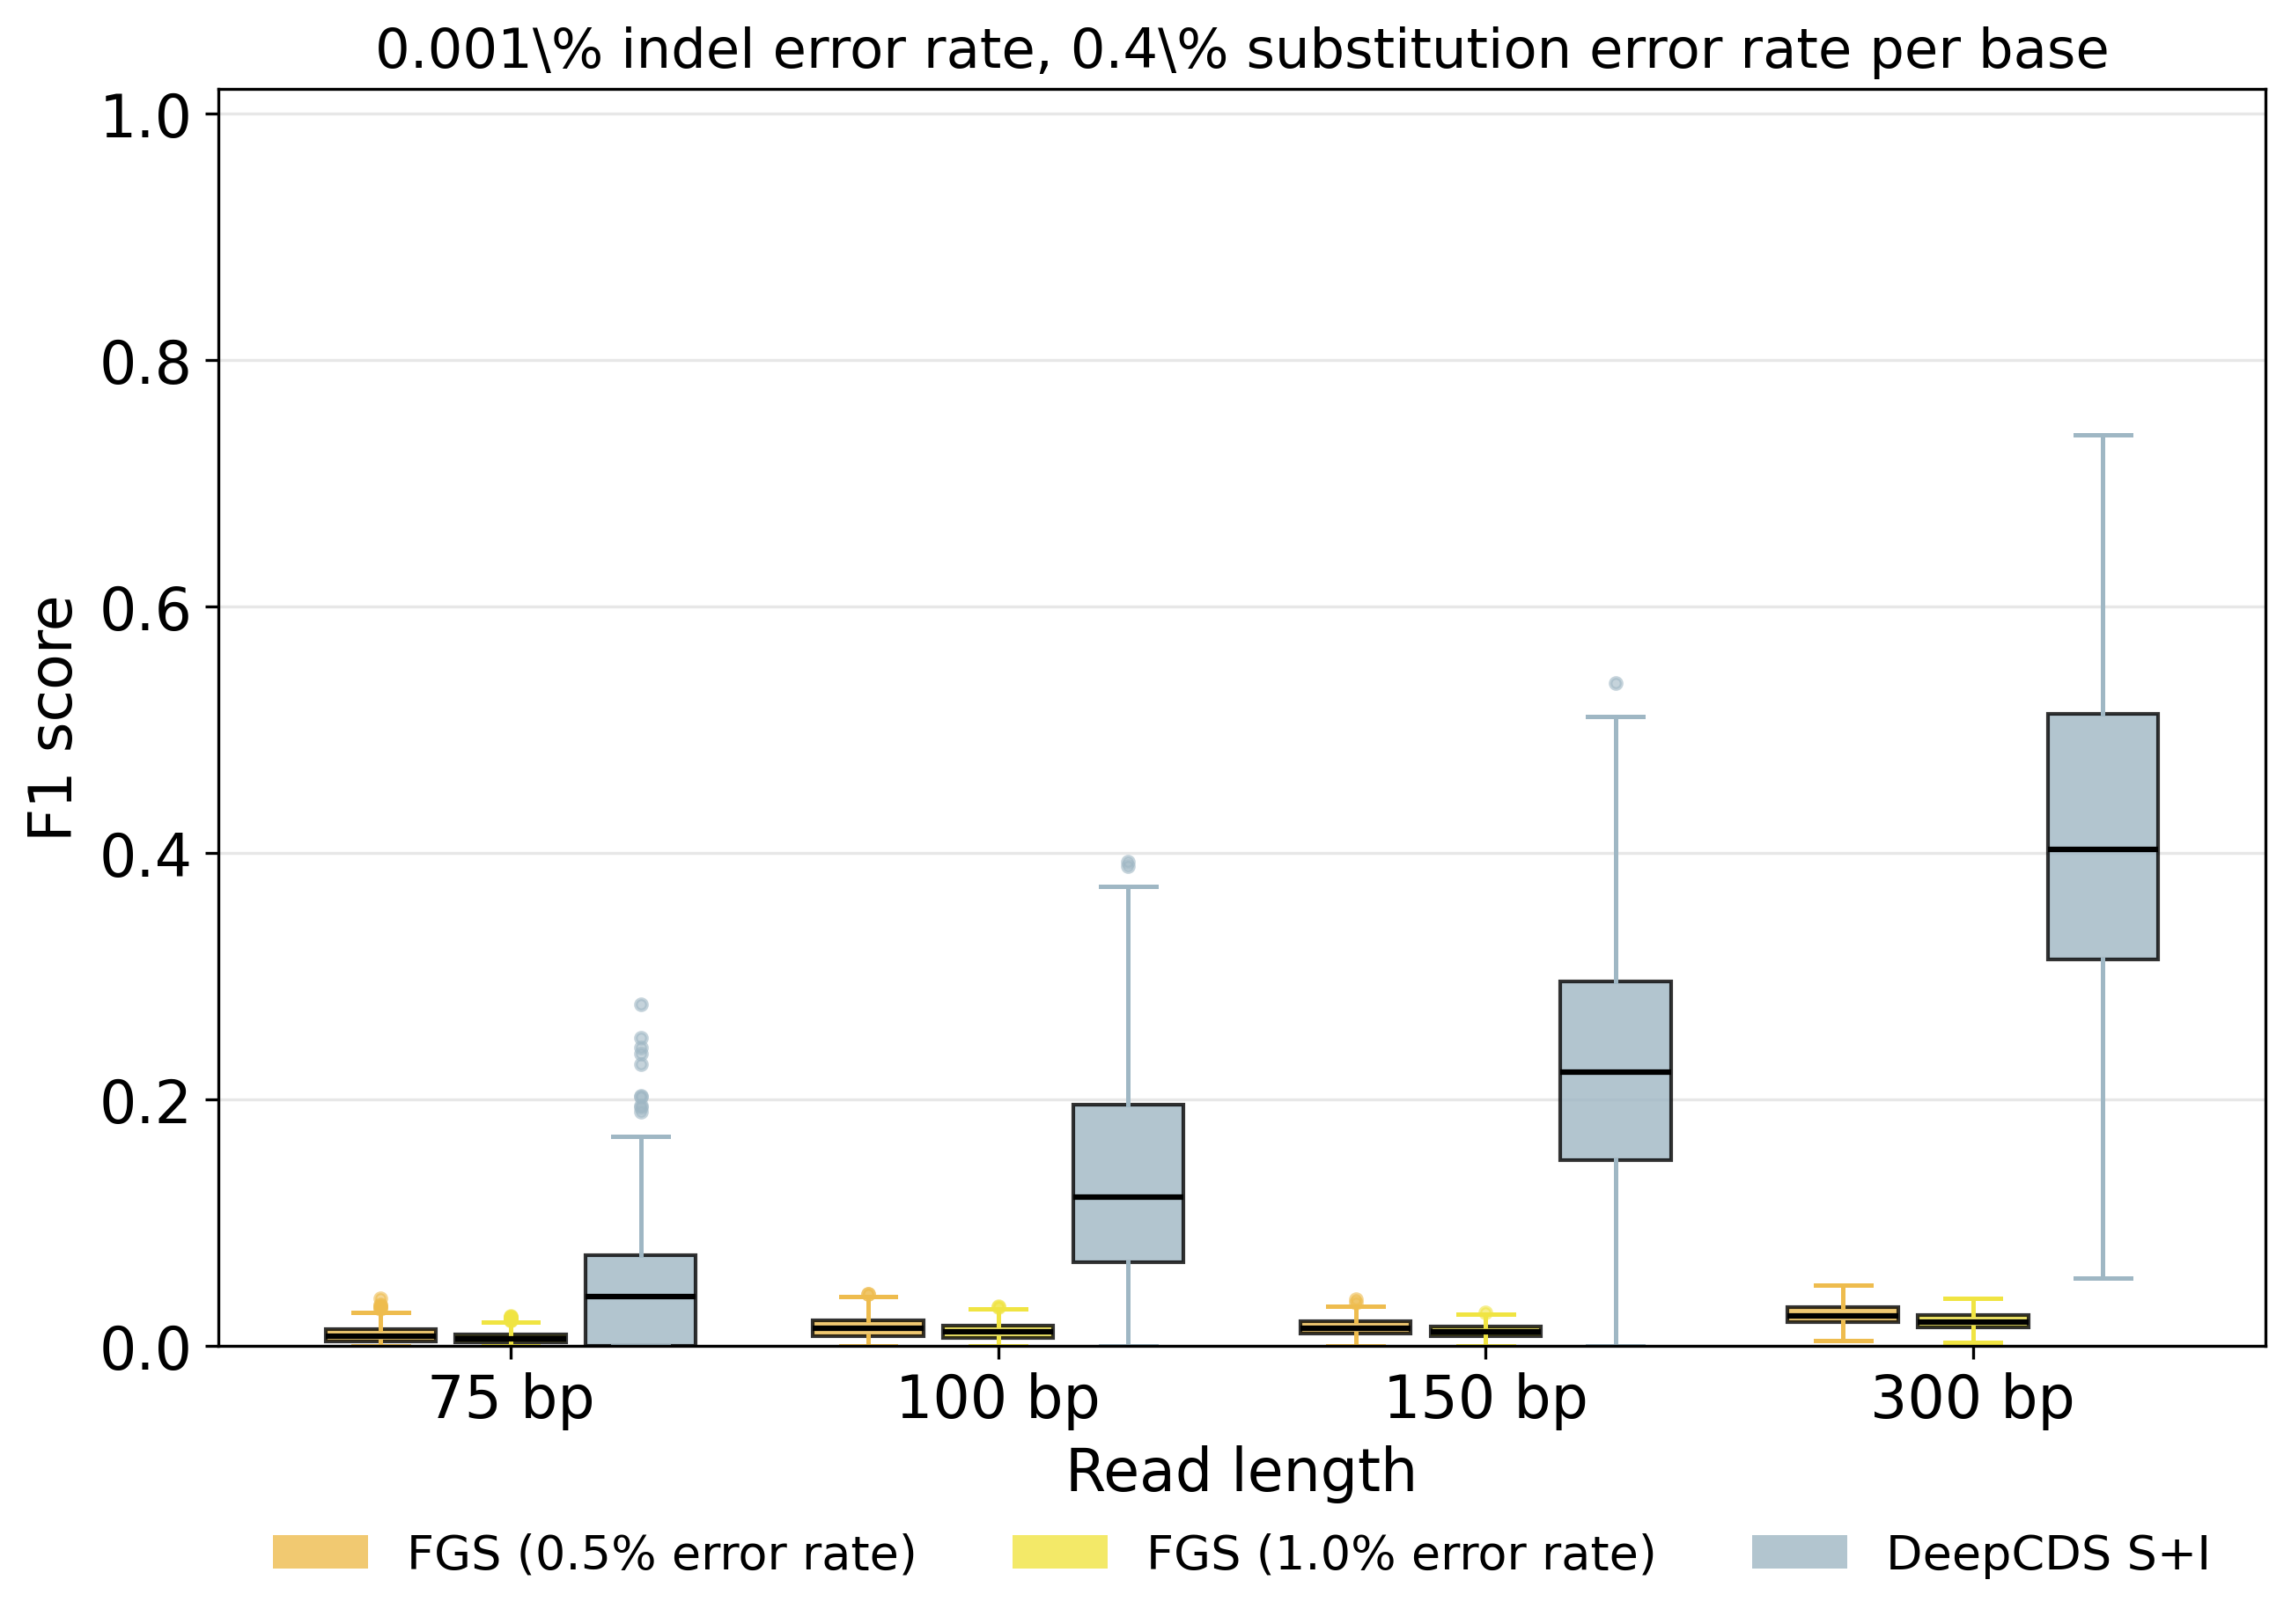

In [22]:
# Render one standalone figure per metric 
plot_metric_boxplot(
    "MAEs", "MAE",
    "boxplot_mae.svg",
    title=f"{error_rate_title}",
    ylim=(-3,71),      # MAE is open-ended; remove fixed y-limits to match highest outlier
)

plot_metric_boxplot(
    "precisions", "Precision",
    "boxplot_precision.svg",
    title=f"{error_rate_title}",
    ylim=(0,1.02), 
)
 
plot_metric_boxplot(
    "sensitivities", "Sensitivity",
    "boxplot_sensitivity.svg",
    title=f"{error_rate_title}",
    ylim=(0,1.02)
)

 
plot_metric_boxplot(
    "f1s", "F1 score",
    "boxplot_f1.svg",
    title=f"{error_rate_title}",
    ylim=(0,1.02)
)
 

In [19]:
# Table 1: genome-level median MAE (median of boxplot distributions)
rows = []
for key in MODEL_KEYS:
    row = {"Model": MODEL_DISPLAY_NAMES[key]}
    for bp in READ_LENGTHS:
        vals = [v for v in results[bp][key]["MAEs"] if not np.isnan(v)]
        row[f"{bp} bp"] = round(np.median(vals), 3) if vals else np.nan
    rows.append(row)

median_mae_table = pd.DataFrame(rows).set_index("Model")
print("Genome-level median MAE")
print(median_mae_table.to_string())

Genome-level median MAE
                       75 bp  100 bp  150 bp  300 bp
Model                                               
FGS (0.5% error rate)  3.889   5.100   6.667   8.924
FGS (1.0% error rate)  4.000   5.333   7.167   9.082
DeepCDS S+I            2.875   3.667   4.714   5.318


In [21]:
# Table 2: fully aggregated MAE (mean ± std across all per-genome MAEs)
rows = []
for key in MODEL_KEYS:
    row = {"Model": MODEL_DISPLAY_NAMES[key]}
    for bp in READ_LENGTHS:
        vals = [v for v in results[bp][key]["MAEs"] if not np.isnan(v)]
        if vals:
            row[f"{bp} bp"] = f"{np.mean(vals):.3f} ± {np.std(vals):.3f}"
        else:
            row[f"{bp} bp"] = np.nan
    rows.append(row)

aggregated_mae_table = pd.DataFrame(rows).set_index("Model")
print("Aggregated MAE (mean ± std across genomes)")
print(aggregated_mae_table.to_string())

Aggregated MAE (mean ± std across genomes)
                               75 bp         100 bp         150 bp          300 bp
Model                                                                             
FGS (0.5% error rate)  4.974 ± 3.644  6.470 ± 5.524  7.740 ± 4.776  11.198 ± 8.464
FGS (1.0% error rate)  5.270 ± 4.018  6.506 ± 4.218  8.270 ± 5.268  11.389 ± 8.098
DeepCDS S+I            3.634 ± 3.567  4.182 ± 2.779  5.395 ± 3.245   5.902 ± 2.865
